In [65]:
# Data Handling
import numpy as np
import pandas as pd
import math
import matplotlib.dates as mdates
from pathlib import Path
from typing import Iterable, Optional, Literal, Any

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Statistical modelling & diagnostics
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Statistical tests
from scipy import stats
from scipy.stats import skewtest, kurtosistest, skew, kurtosis, boxcox, jarque_bera, shapiro, boxcox_llf, boxcox_normmax, chi2, normaltest, norm

# Warnings
import warnings
warnings.filterwarnings("ignore")

---

    - Function to format results into a table

In [66]:
def display_table(df: pd.DataFrame, title: str):
    """
    Display a formatted table for quick analysis and validation of results.

    Parameters
    ----------
    df (pd.DataFrame): DataFrame to be displayed.
    title (str): Title printed above the table.


    Returns
    -------
    df (pd.DataFrame)
    """

    print(f"\n{title}")
    if df.empty or df.shape[1] == 0:
        print("⚠️ No valid data or columns not found.")
        return

    colalign = ["center"] * len(df.columns)
    print(tabulate(df, headers="keys", tablefmt="fancy_grid", colalign=colalign, showindex=True, floatfmt=".4f"))

    - Function to compute Freedman–Diaconis bins

In [67]:
def freedman_diaconis_bins(df: pd.DataFrame):
    """
    Compute the number of histogram bins using the Freedman–Diaconis rule.
    The FD rule sets the bin width as:
        width = 2 * IQR / n^(1/3)
    where IQR is the interquartile range (Q3 - Q1) and n is the sample size.

    Parameters
    ----------
    df (pd.DataFrame): One-dimensional numeric data.

    Returns
    -------
    n_bins (int): Suggested number of bins.
    iqr_range (float): Suggested bin IQR range.
    """

    # Length of dataframe
    n = df.size
    if n == 0:
        return print("Dataframe is empty")
    
    # IQR range calculation
    q75, q25 = np.percentile(df, [75, 25])
    iqr = q75 - q25
    iqr_range = 2.0 * iqr / (n**(1/3))

    # Bins calculation
    data_range = np.max(df) - np.min(df)
    n_bins = int(math.ceil(data_range / iqr_range)) if iqr_range > 0 else 1

    return n_bins, iqr_range

    - Function to compute the Box–Cox Log-Likelihood Profile: Grid of λ, MLE and LR-Based CI

In [68]:
def plot_boxcox_likelihood_profile(df: pd.DataFrame):
    """
    Plot the Box–Cox log-likelihood profile and return key results.

    This function evaluates the Box–Cox log-likelihood over a grid of λ values, obtains the maximum-likelihood estimate (MLE) of λ using SciPy, constructs an approximate 95% likelihood-ratio confidence interval, applies the
    Box–Cox transform at the MLE, and produces a diagnostic plot.

    Parameters
    ----------
    df (pandas.DataFrame): Single-column DataFrame of strictly positive, finite values. The index is preserved for the returned transformed series.

    Returns
    -------
    dict
        Dictionary with:
        - loglik (numpy.ndarray): log-likelihood values (up to an additive constant).
        - lambda_mle_scipy (float): λ maximizing the log-likelihood via scipy.stats.boxcox_normmax(method="mle").
        - ci95 (tuple[float, float]): 95% likelihood-ratio confidence interval for λ, using the cutoff max(loglik) - 0.5 * chi2.ppf(0.95, df=1)`.
        - df_bc (pandas.Series): data transformed with the MLE λ, aligned to df's index.
    """

    # Dataframe values verification
    if (df <= 0).to_numpy().any():
        raise ValueError("Dataframe canot have values <= 0.")

    # Grid and log-likelihood profile
    lambdas = np.linspace(-1, 1.6, 400)
    loglik = np.array([boxcox_llf(l, df) for l in lambdas])

    # MLE (Maximum Likelihood Estimation)
    lambda_mle_scipy = float(boxcox_normmax(df, method="mle"))

    # 95% CI via Likelihood-Ratio (Wilks)
    cutoff = loglik.max() - 0.5 * chi2.ppf(0.95, df=1)
    inside = loglik >= cutoff
    if inside.any():
        lo_idx = np.where(inside)[0][0]
        hi_idx = np.where(inside)[0][-1]
        ci95 = (float(lambdas[lo_idx]), float(lambdas[hi_idx]))
    else:
        ci95 = (np.nan, np.nan)

    # Transform using MLE
    df_bc = pd.Series(boxcox(df.values, lmbda=lambda_mle_scipy), index=df.index, name=f"Box-Cox(λ={lambda_mle_scipy:.4f})")

    # Plot    
    fig, ax = plt.subplots(figsize=(20, 5))
    ax.plot(lambdas, loglik, lw=2)
    ax.axvline(0, color="gray", ls="--", lw=1, label="log (λ = 0)")
    ax.axvline(lambda_mle_scipy, color="#D55E00", ls="-.", lw=1.8, label=f"MLE λ ≈ {lambda_mle_scipy:.4f}")

    if np.isfinite(ci95[0]):
        ax.hlines(cutoff, ci95[0], ci95[1], colors="#009E73", linestyles=":", lw=2, label="95% LR cutoff")
        ax.vlines([ci95[0], ci95[1]], np.nanmin(loglik), cutoff, colors="#009E73", linestyles=":")

    ax.set_xlabel("λ (Box–Cox power)")
    ax.set_ylabel("Log-likelihood (up to constant)")
    ax.set_title("Box–Cox likelihood profile — Bitcoin closing prices")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1, 1.6)
    ax.set_xticks(np.arange(-1.2, 1.8, 0.2))
    ax.legend(loc="best")

    plt.tight_layout()
    # plt.show()

    return {"loglik": loglik,
            "lambda_mle_scipy": lambda_mle_scipy,
            "ci95": ci95,
            "df_bc": df_bc}

    - Function to compute Hodrick–Prescott Filter and λ Selection

In [69]:
def hp_lambda(k_per_year: float):
    """
    Hodrick-Prescott filter:
    Calculates the λ parameter for the HP filter for different data frequencies, according to the rule of Ravn & Uhlig (2002), 
    and returns predefined values along with the calculation for the given k.
    See Ravn and Uhlig: http://home.uchicago.edu/~huhlig/papers/uhlig.ravn.res.2002.pdf

    Parameters:
    -----------
    k_per_year (float): Number of observations per year.
   
    Returns:
    --------
    lamda_hp (float): λ value
    """

    lamda_hp = 1600 * (k_per_year / 4) ** 4
        
    return lamda_hp

    - Cumsum

In [70]:
def detect_cusum(x, threshold=1, drift=0, ending=False, show=True, ax=None):
    """Cumulative sum algorithm (CUSUM) to detect abrupt changes in data.
    __author__ = 'Marcos Duarte, https://github.com/demotu/BMC'
    __version__ = "1.0.4"
    __license__ = "MIT"
    Parameters
    ----------
    x : 1D array_like
        data.
    threshold : positive number, optional (default = 1)
        amplitude threshold for the change in the data.
    drift : positive number, optional (default = 0)
        drift term that prevents any change in the absence of change.
    ending : bool, optional (default = False)
        True (1) to estimate when the change ends; False (0) otherwise.
    show : bool, optional (default = True)
        True (1) plots data in matplotlib figure, False (0) don't plot.
    ax : a matplotlib.axes.Axes instance, optional (default = None).
    Returns
    -------
    ta : 1D array_like [indi, indf], int
        alarm time (index of when the change was detected).
    tai : 1D array_like, int
        index of when the change started.
    taf : 1D array_like, int
        index of when the change ended (if `ending` is True).
    amp : 1D array_like, float
        amplitude of changes (if `ending` is True).
    Notes
    -----
    Tuning of the CUSUM algorithm according to Gustafsson (2000)[1]_:
    Start with a very large `threshold`.
    Choose `drift` to one half of the expected change, or adjust `drift` such
    that `g` = 0 more than 50% of the time.
    Then set the `threshold` so the required number of false alarms (this can
    be done automatically) or delay for detection is obtained.
    If faster detection is sought, try to decrease `drift`.
    If fewer false alarms are wanted, try to increase `drift`.
    If there is a subset of the change times that does not make sense,
    try to increase `drift`.
    Note that by default repeated sequential changes, i.e., changes that have
    the same beginning (`tai`) are not deleted because the changes were
    detected by the alarm (`ta`) at different instants. This is how the
    classical CUSUM algorithm operates.
    If you want to delete the repeated sequential changes and keep only the
    beginning of the first sequential change, set the parameter `ending` to
    True. In this case, the index of the ending of the change (`taf`) and the
    amplitude of the change (or of the total amplitude for a repeated
    sequential change) are calculated and only the first change of the repeated
    sequential changes is kept. In this case, it is likely that `ta`, `tai`,
    and `taf` will have less values than when `ending` was set to False.
    See this IPython Notebook [2]_.
    References
    ----------
    .. [1] Gustafsson (2000) Adaptive Filtering and Change Detection.
    .. [2] hhttp://nbviewer.ipython.org/github/demotu/BMC/blob/master/notebooks/DetectCUSUM.ipynb
    Examples
    --------
    >>> from detect_cusum import detect_cusum
    >>> x = np.random.randn(300)/5
    >>> x[100:200] += np.arange(0, 4, 4/100)
    >>> ta, tai, taf, amp = detect_cusum(x, 2, .02, True, True)
    >>> x = np.random.randn(300)
    >>> x[100:200] += 6
    >>> detect_cusum(x, 4, 1.5, True, True)
    >>> x = 2*np.sin(2*np.pi*np.arange(0, 3, .01))
    >>> ta, tai, taf, amp = detect_cusum(x, 1, .05, True, True)
    """

    x = np.atleast_1d(x).astype('float64')
    gp, gn = np.zeros(x.size), np.zeros(x.size)
    ta, tai, taf = np.array([[], [], []], dtype=int)
    tap, tan = 0, 0
    amp = np.array([])
    # Find changes (online form)
    for i in range(1, x.size):
        s = x[i] - x[i-1]
        gp[i] = gp[i-1] + s - drift  # cumulative sum for + change
        gn[i] = gn[i-1] - s - drift  # cumulative sum for - change
        if gp[i] < 0:
            gp[i], tap = 0, i
        if gn[i] < 0:
            gn[i], tan = 0, i
        if gp[i] > threshold or gn[i] > threshold:  # change detected!
            ta = np.append(ta, i)    # alarm index
            tai = np.append(tai, tap if gp[i] > threshold else tan)  # start
            gp[i], gn[i] = 0, 0      # reset alarm
    # THE CLASSICAL CUSUM ALGORITHM ENDS HERE

    # Estimation of when the change ends (offline form)
    if tai.size and ending:
        _, tai2, _, _ = detect_cusum(x[::-1], threshold, drift, show=False)
        taf = x.size - tai2[::-1] - 1
        # Eliminate repeated changes, changes that have the same beginning
        tai, ind = np.unique(tai, return_index=True)
        ta = ta[ind]
        # taf = np.unique(taf, return_index=False)  # corect later
        if tai.size != taf.size:
            if tai.size < taf.size:
                taf = taf[[np.argmax(taf >= i) for i in ta]]
            else:
                ind = [np.argmax(i >= ta[::-1])-1 for i in taf]
                ta = ta[ind]
                tai = tai[ind]
        # Delete intercalated changes (the ending of the change is after
        # the beginning of the next change)
        ind = taf[:-1] - tai[1:] > 0
        if ind.any():
            ta = ta[~np.append(False, ind)]
            tai = tai[~np.append(False, ind)]
            taf = taf[~np.append(ind, False)]
        # Amplitude of changes
        amp = x[taf] - x[tai]

    if show:
        _plot(x, threshold, drift, ending, ax, ta, tai, taf, gp, gn)

    return ta, tai, taf, amp

def _plot(x, threshold, drift, ending, ax, ta, tai, taf, gp, gn):
    """Plot results of the detect_cusum function, see its help."""

    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print('matplotlib is not available.')
    else:
        if ax is None:
            _, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))

        t = range(x.size)
        ax1.plot(t, x, 'b-', lw=2)
        if len(ta):
            ax1.plot(tai, x[tai], '>', mfc='g', mec='g', ms=10,
                     label='Start')
            if ending:
                ax1.plot(taf, x[taf], '<', mfc='g', mec='g', ms=10,
                         label='Ending')
            ax1.plot(ta, x[ta], 'o', mfc='r', mec='r', mew=1, ms=5,
                     label='Alarm')
            ax1.legend(loc='best', framealpha=.5, numpoints=1)
        ax1.set_xlim(-.01*x.size, x.size*1.01-1)
        ax1.set_xlabel('Data #', fontsize=14)
        ax1.set_ylabel('Amplitude', fontsize=14)
        ymin, ymax = x[np.isfinite(x)].min(), x[np.isfinite(x)].max()
        yrange = ymax - ymin if ymax > ymin else 1
        ax1.set_ylim(ymin - 0.1*yrange, ymax + 0.1*yrange)
        ax1.set_title('Time series and detected changes ' +
                      '(threshold= %.3g, drift= %.3g): N changes = %d'
                      % (threshold, drift, len(tai)))
        ax2.plot(t, gp, 'y-', label='+')
        ax2.plot(t, gn, 'm-', label='-')
        ax2.set_xlim(-.01*x.size, x.size*1.01-1)
        ax2.set_xlabel('Data #', fontsize=14)
        ax2.set_ylim(-0.01*threshold, 1.1*threshold)
        ax2.axhline(threshold, color='r')
        ax1.set_ylabel('Amplitude', fontsize=14)
        ax2.set_title('Time series of the cumulative sums of ' +
                      'positive and negative changes')
        ax2.legend(loc='best', framealpha=.5, numpoints=1)
        plt.tight_layout()
        plt.show()

---

In [71]:
# Upload of Time-Series data
def load_series_from_csv(csv_path: str | Path, value_col: str, index_col: int | str = 0, dayfirst: bool = True, sort_index: bool = True, name: str = "y"):
    """
    Load a univariate time series from a CSV file.

    Notes
    -----
    - Expects the time index in `index_col`.
    - Converts index to datetime.
    - Returns a pd.Series with a clean name.
    """
    
    csv_path = Path(csv_path)
    df_raw = pd.read_csv(csv_path, index_col=index_col)
    df_raw.index = pd.to_datetime(df_raw.index, dayfirst=dayfirst, errors="coerce")
    df_raw = df_raw.rename_axis("Date")

    if df_raw.index.isna().any():
        raise ValueError("Warning: Datetime conversion produced NaT values in the index. Please check the CSV index format.")

    if sort_index:
        if not df_raw.index.is_monotonic_increasing:
            df_raw = df_raw.sort_index()
            print("Warning: Datetime index was not sorted. It has been automatically sorted.")

    if value_col not in df_raw.columns:
        raise KeyError(f"Column '{value_col}' not found. Available columns: {list(df_raw.columns)}")

    y = df_raw[value_col].copy()
    
    y.name = name
    return y

df_path = r"D:\Hnsx\Formação Superior\0_Universidade Europeia\Mestrado em Ciência de Dados e Análise de Negócios\Curso\Tese_DataScience\Código\BTC-USD_2025-08-15.csv"
y_temp = load_series_from_csv(csv_path= df_path, value_col= "Close", name= "Close")

# Série de valores de fecho
# y_close = y_temp.copy()
# y = y_close.copy()

# Return type and transformations
ret_type = "L"                         # "S" simple returns | "L" log returns

# Return series
if ret_type == "S":
    y_returns = pd.Series(y_temp.pct_change(), name=f"Returns({ret_type}) series").dropna()
elif ret_type == "L":
    y_returns = pd.Series(np.log(y_temp / y_temp.shift(1)), name=f"Returns({ret_type}) series").dropna()
else:
    raise ValueError("ret_type deve ser 'S' ou 'L'.")
y = y_returns.copy()
y

Date
2014-09-18   -0.074643
2014-09-19   -0.072402
2014-09-20    0.035111
2014-09-21   -0.024968
2014-09-22    0.008317
                ...   
2025-08-10    0.023804
2025-08-11   -0.004834
2025-08-12    0.012067
2025-08-13    0.026046
2025-08-14   -0.041250
Name: Returns(L) series, Length: 3984, dtype: float64

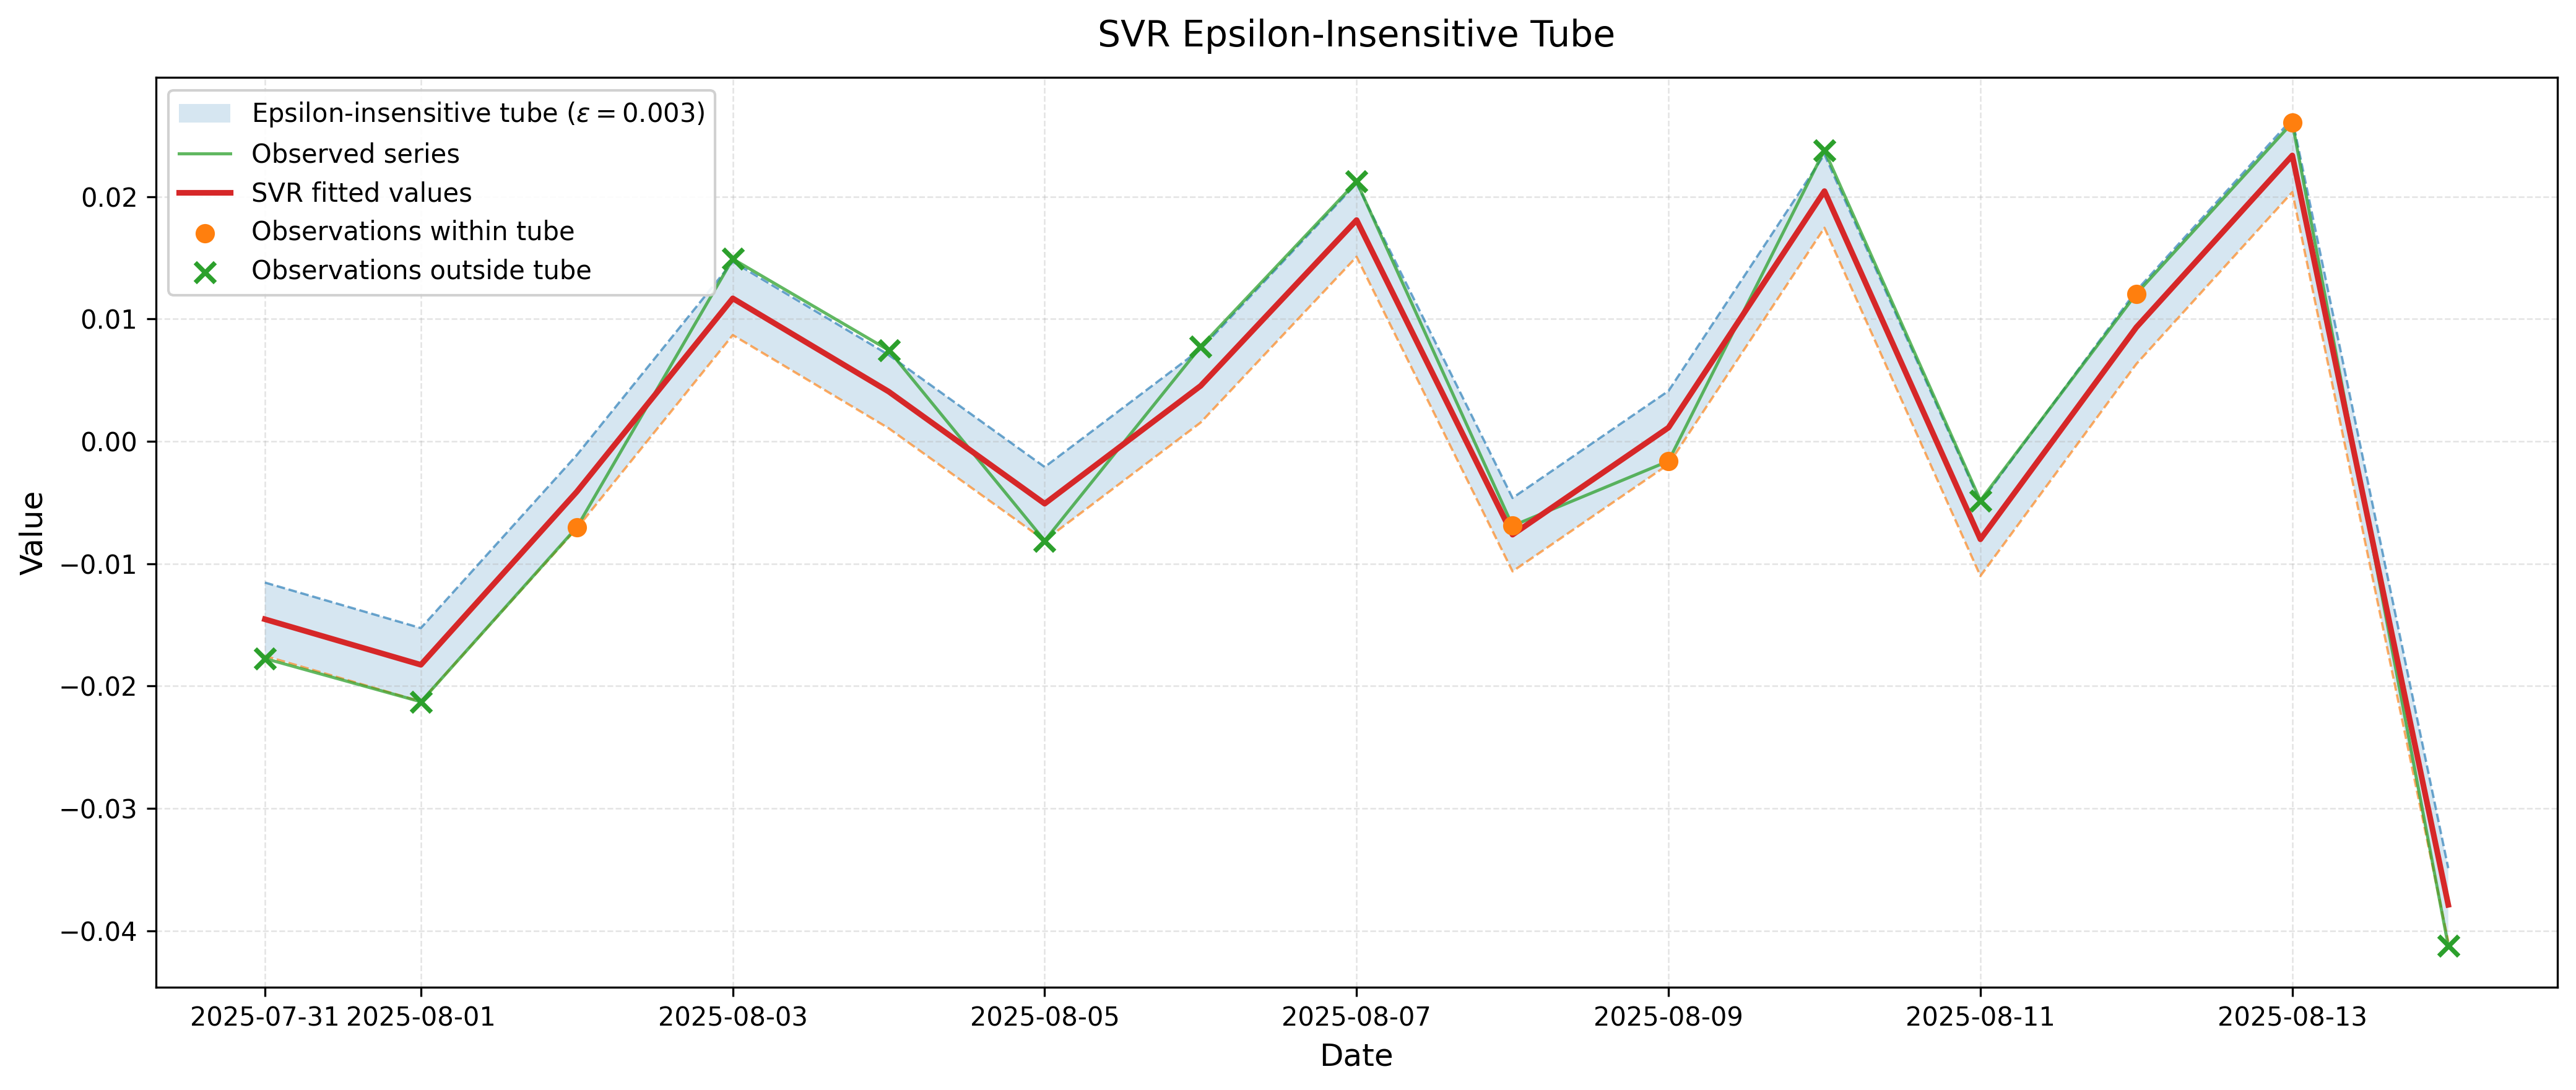

Usable observations after lag creation: 15
Epsilon used: 0.00300
Observations within tube: 5
Observations outside tube: 10


In [72]:
def criar_lags(serie: pd.Series, n_lags: int = 5):
    """
    Converte uma série temporal num problema supervisionado com lags.
    """

    if not isinstance(serie, pd.Series):
        raise TypeError("serie must be a pandas Series.")

    if n_lags < 1:
        raise ValueError("n_lags must be >= 1.")

    df = pd.DataFrame({"y": serie.copy()})

    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)

    df = df.dropna()

    X = df.drop(columns="y").values
    y = df["y"].values
    idx = df.index

    return X, y, idx


def plot_insensitive_tube_svr(serie: pd.Series, n_lags: int = 3, C: float = 10.0, epsilon: float | str = "auto", epsilon_ratio: float = 0.35, kernel: str = "rbf",
                              gamma: str = "scale", figsize=(14, 6), dpi: int = 300):
    """
    Fit an SVR model to a time series and plot the epsilon-insensitive tube.

    If epsilon="auto", epsilon is defined as epsilon_ratio * std(y),
    where y is the supervised target after lag creation.
    """

    if not isinstance(serie, pd.Series):
        raise TypeError("The variable 'serie' must be a pd.Series.")

    serie = serie.copy().replace([np.inf, -np.inf], np.nan).dropna()

    if len(serie) <= n_lags:
        raise ValueError(f"The series has {len(serie)} observations, but n_lags={n_lags}. You need more observations than lags.")

    X, y_target, idx = criar_lags(serie, n_lags=n_lags)

    if len(y_target) < 10:
        raise ValueError(f"Only {len(y_target)} usable observations remain after lag creation. Use fewer lags or a longer series.")

    if epsilon == "auto":
        epsilon_used = epsilon_ratio * np.std(y_target, ddof=1)
    else:
        epsilon_used = float(epsilon)

    if epsilon_used <= 0:
        raise ValueError("epsilon must be positive.")

    modelo = Pipeline([("scaler_X", StandardScaler()),
                       ("svr", SVR(C=C, epsilon=epsilon_used, kernel=kernel, gamma=gamma))])

    modelo.fit(X, y_target)
    y_pred = modelo.predict(X)

    df_plot = pd.DataFrame({"Actual": y_target,
                            "Predicted": y_pred,
                            "Upper Bound": y_pred + epsilon_used,
                            "Lower Bound": y_pred - epsilon_used}, index=idx)

    df_plot.index = pd.to_datetime(df_plot.index)
    df_plot = df_plot.sort_index()

    dentro_tubo = ((df_plot["Actual"] >= df_plot["Lower Bound"]) & (df_plot["Actual"] <= df_plot["Upper Bound"]))

    fora_tubo = ~dentro_tubo

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    ax.fill_between(df_plot.index, df_plot["Lower Bound"].values, df_plot["Upper Bound"].values, alpha=0.18, label=rf"Epsilon-insensitive tube ($\epsilon={epsilon_used:.3f}$)",
                    zorder=1)

    ax.plot(df_plot.index, df_plot["Upper Bound"], linestyle="--", linewidth=0.9, alpha=0.65, zorder=2)

    ax.plot(df_plot.index, df_plot["Lower Bound"], linestyle="--", linewidth=0.9, alpha=0.65, zorder=2)

    ax.plot(df_plot.index, df_plot["Actual"], label="Observed series", linewidth=1.2, alpha=0.75, zorder=3)

    ax.plot(df_plot.index, df_plot["Predicted"], label="SVR fitted values", linewidth=2.2, zorder=4)

    ax.scatter(df_plot.index[dentro_tubo], df_plot.loc[dentro_tubo, "Actual"], s=42, label="Observations within tube", zorder=5)

    ax.scatter(df_plot.index[fora_tubo], df_plot.loc[fora_tubo, "Actual"], s=60, marker="x", linewidths=1.8, label="Observations outside tube", zorder=6)

    ax.set_title("SVR Epsilon-Insensitive Tube", pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")

    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax.legend(loc="upper left", frameon=True, framealpha=0.90)

    fig.tight_layout()
    plt.show()

    print(f"Usable observations after lag creation: {len(y_target)}")
    print(f"Epsilon used: {epsilon_used:.5f}")
    print(f"Observations within tube: {dentro_tubo.sum()}")
    print(f"Observations outside tube: {fora_tubo.sum()}")

    return modelo, df_plot

serie = pd.Series(y[-20:], name="serie")

modelo, df_resultado = plot_insensitive_tube_svr(serie=serie, n_lags=5, C=10, epsilon=0.003, kernel="rbf", gamma="scale")

---

In [73]:
# Time-based train/val/test split
def time_split(y: pd.Series, test_size: float = 0.2, test_start: Optional[str | pd.Timestamp] = None, val_size: float = 0.3):
    """
    Split a time series into train/val/test.

    Parameters
    ----------
    test_start : str | pd.Timestamp | None
        If provided, test starts at this timestamp (inclusive).
        If None, uses test_size percentage.
    val_size : float
        Fraction of the training portion used as validation (0 disables validation split).

    Returns
    -------
    y_train, y_val, y_test
    """
    y = y.copy()
    if test_start is not None:
        test_start = pd.to_datetime(test_start)
        y_train_full = y.loc[y.index < test_start]
        y_test = y.loc[y.index >= test_start]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Date-based split produced empty train or test. Check test_start.")
    else:
        if not (0 < test_size < 1):
            raise ValueError("test_size must be in (0,1).")
        cut = int(len(y) * (1 - test_size))
        y_train_full = y.iloc[:cut]
        y_test = y.iloc[cut:]
        if y_train_full.empty or y_test.empty:
            raise ValueError("Percentage split produced empty train or test. Adjust test_size.")

    if not (0 < val_size < 1):
        raise ValueError("val_size must be in (0,1).")

    cut_val = int(len(y_train_full) * (1 - val_size))
    y_train = y_train_full.iloc[:cut_val]
    y_val = y_train_full.iloc[cut_val:]

    if y_train.empty or y_val.empty:
        raise ValueError("Validation split produced empty train or val. Adjust val_size.")

    return y_train, y_val, y_test

y_train, y_val, y_test = time_split(y= y, test_start= None, val_size= 0.3)

print(f"Length of training dataset: {len(y_train)}")
print(f"Length of validation dataset: {len(y_val)}")
print(f"Length of test dataset: {len(y_test)}")

Length of training dataset: 2230
Length of validation dataset: 957
Length of test dataset: 797


In [74]:
# Target variable transformations
scale_transformer = None
transformation_type = "log1p"     # "original" | "log1p" | "yeo-johnson"

# Target variable construction: volatility proxy
v_train = y_train.pow(2)
v_val = y_val.pow(2)
v_test = y_test.pow(2)

if transformation_type == "original":
    # Volatility proxy: squared returns
    y_train = pd.Series(v_train, index=v_train.index, name=f"Variance_ret({ret_type}) series")
    y_val = pd.Series(v_val, index=v_val.index, name=f"Variance_ret({ret_type}) series")
    y_test = pd.Series(v_test, index=v_test.index, name=f"Variance_ret({ret_type}) series")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "log1p":
    # Log transformation without scale factor
    y_train = pd.Series(np.log1p(v_train), index=v_train.index, name=f"Log-Variance_ret({ret_type}) series")
    y_val = pd.Series(np.log1p(v_val), index=v_val.index, name=f"Log-Variance_ret({ret_type}) series")
    y_test = pd.Series(np.log1p(v_test), index=v_test.index, name=f"Log-Variance_ret({ret_type}) series")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "yeo-johnson":
    # Yeo-Johnson transformation without scale factor
    scale_transformer = PowerTransformer(method="yeo-johnson", standardize=False)

    y_train = pd.Series(scale_transformer.fit_transform(v_train.to_frame()).flatten(), index=v_train.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_val = pd.Series(scale_transformer.transform(v_val.to_frame()).flatten(), index=v_val.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_test = pd.Series(scale_transformer.transform(v_test.to_frame()).flatten(), index=v_test.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")

    print("Yeo-Johnson lambda:", scale_transformer.lambdas_)
    print("Train transformed - min/max:", y_train.min(), y_train.max())
    print("Validation transformed - min/max:", y_val.min(), y_val.max())
    print("Test transformed - min/max:", y_test.min(), y_test.max())

    serie_cache_name = y_train.name.strip("'").split()[0]

else:
    raise ValueError("transformation_type must be 'original', 'log1p' or 'yeo-johnson'.")

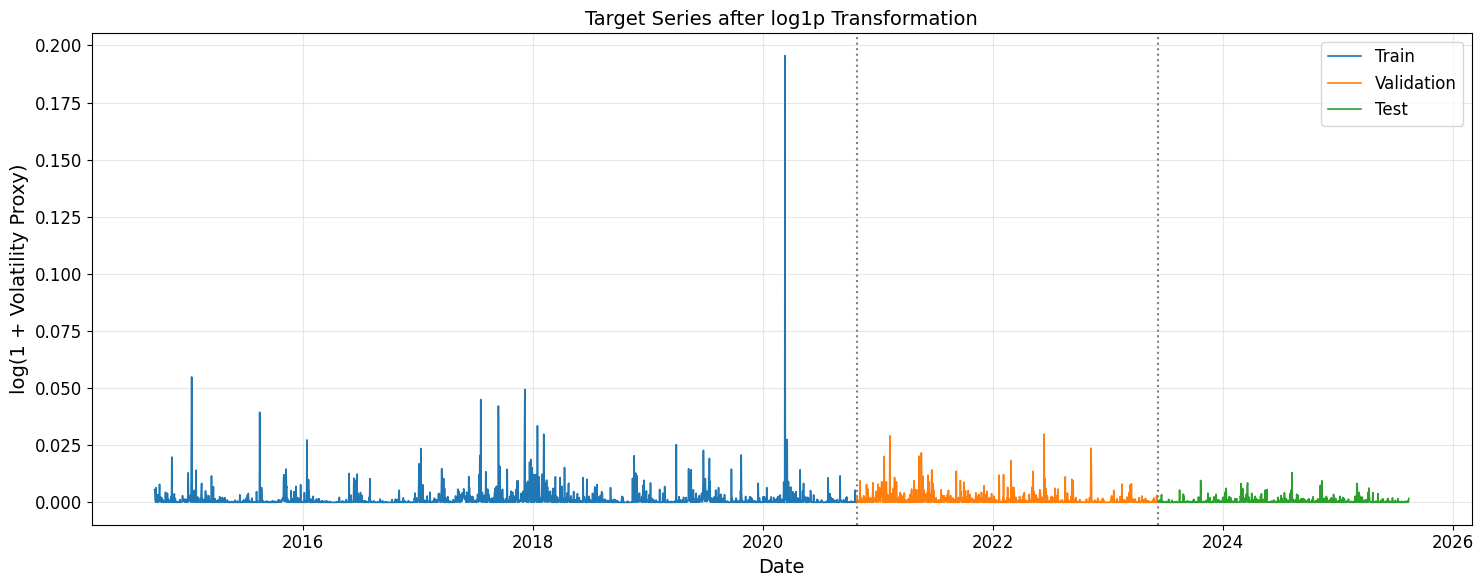

In [75]:
# Plot transformed target series used by the model
def plot_transformed_target_series(y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, transformation_type: str, figsize=(15, 6)):
    """
    Plot the target series after the selected transformation.
    This shows the exact series used as input target by the forecasting models.
    """

    if not isinstance(y_train, pd.Series) or not isinstance(y_val, pd.Series) or not isinstance(y_test, pd.Series):
        raise TypeError("y_train, y_val and y_test must be pandas Series.")

    y_train_plot = y_train.copy()
    y_val_plot = y_val.copy()
    y_test_plot = y_test.copy()

    y_train_plot.index = pd.to_datetime(y_train_plot.index)
    y_val_plot.index = pd.to_datetime(y_val_plot.index)
    y_test_plot.index = pd.to_datetime(y_test_plot.index)

    plt.figure(figsize=figsize)

    plt.plot(y_train_plot.index, y_train_plot.values, label="Train", linewidth=1.2)
    plt.plot(y_val_plot.index, y_val_plot.values, label="Validation", linewidth=1.2)
    plt.plot(y_test_plot.index, y_test_plot.values, label="Test", linewidth=1.2)

    plt.axvline(y_val_plot.index[0], linestyle=":", linewidth=1.5, color="grey")
    plt.axvline(y_test_plot.index[0], linestyle=":", linewidth=1.5, color="grey")

    plt.title(f"Target Series after {transformation_type} Transformation", fontsize=14)
    plt.xlabel("Date", fontsize=14)

    if transformation_type == "original":
        ylabel = "Volatility Proxy"
    elif transformation_type == "log1p":
        ylabel = "log(1 + Volatility Proxy)"
    elif transformation_type == "yeo-johnson":
        ylabel = "Yeo-Johnson Transformed Volatility Proxy"
    else:
        ylabel = "Transformed Target"

    plt.ylabel(ylabel, fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_transformed_target_series(y_train=y_train, y_val=y_val, y_test=y_test, transformation_type=transformation_type)

In [76]:
# Summary statistics of transformed target series
summary_transformed_target = pd.DataFrame({"Phase": ["Train", "Validation", "Test"],
                                           "Min": [y_train.min(), y_val.min(), y_test.min()],
                                           "Median": [y_train.median(), y_val.median(), y_test.median()],
                                           "Mean": [y_train.mean(), y_val.mean(), y_test.mean()],
                                           "Std": [y_train.std(ddof=1), y_val.std(ddof=1), y_test.std(ddof=1)],
                                           "Max": [y_train.max(), y_val.max(), y_test.max()]})

display_table(summary_transformed_target, f"Summary statistics - transformed target ({transformation_type})")


Summary statistics - transformed target (log1p)
╒════╤════════════╤════════╤══════════╤════════╤════════╤════════╕
│    │   Phase    │  Min   │  Median  │  Mean  │  Std   │    Max │
╞════╪════════════╪════════╪══════════╪════════╪════════╪════════╡
│ 0  │   Train    │ 0.0000 │  0.0002  │ 0.0015 │ 0.0056 │ 0.1955 │
├────┼────────────┼────────┼──────────┼────────┼────────┼────────┤
│ 1  │ Validation │ 0.0000 │  0.0003  │ 0.0013 │ 0.0028 │ 0.0298 │
├────┼────────────┼────────┼──────────┼────────┼────────┼────────┤
│ 2  │    Test    │ 0.0000 │  0.0001  │ 0.0006 │ 0.0013 │ 0.0131 │
╘════╧════════════╧════════╧══════════╧════════╧════════╧════════╛


In [77]:
# Target variable transformations with scale factor
scale_transformer = None        # PowerTransformer(method="yeo-johnson", standardize=False) --- IGNORE ---
transformation_type = "log1p"     # "original" | "log1p" | "yeo-johnson"

# Target variable construction: volatility proxy
v_train = y_train.pow(2)
v_val = y_val.pow(2)
v_test = y_test.pow(2)

if transformation_type == "original":
    # Volatilidade proxy (squared returns)
    y_train = pd.Series(v_train, name=f"Variance_ret({ret_type}) series")
    y_val = pd.Series(v_val, name=f"Variance_ret({ret_type}) series")
    y_test = pd.Series(v_test, name=f"Variance_ret({ret_type}) series")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "log1p":
    scale_factor = 1e5

    v_train_scaled = v_train * scale_factor
    v_val_scaled = v_val * scale_factor
    v_test_scaled = v_test * scale_factor

    # Log transformation
    y_train = pd.Series(np.log1p(v_train_scaled), name=f"Log-Variance_ret({ret_type}) series_st")
    y_val = pd.Series(np.log1p(v_val_scaled), name=f"Log-Variance_ret({ret_type}) series_st")
    y_test = pd.Series(np.log1p(v_test_scaled), name=f"Log-Variance_ret({ret_type}) series_st")

    serie_cache_name = y_train.name.strip("'").split()[0]

elif transformation_type == "yeo-johnson":
    scale_factor = 1e6

    v_train_scaled = v_train * scale_factor
    v_val_scaled = v_val * scale_factor
    v_test_scaled = v_test * scale_factor

    # Yeo–Johnson transformation
    scale_transformer = PowerTransformer(method="yeo-johnson", standardize=False)
    y_train = pd.Series(scale_transformer.fit_transform(v_train_scaled.to_frame()).flatten(), index=v_train.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_val = pd.Series(scale_transformer.transform(v_val_scaled.to_frame()).flatten(), index=v_val.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")
    y_test = pd.Series(scale_transformer.transform(v_test_scaled.to_frame()).flatten(), index=v_test.index, name=f"Yeo-Johnson-Variance_ret({ret_type}) series")

    print("Yeo-Johnson lambda:", scale_transformer.lambdas_)
    print("Train transformed - min/max:", y_train.min(), y_train.max())
    print("Validation transformed - min/max:", y_val.min(), y_val.max())
    print("Test transformed - min/max:", y_test.min(), y_test.max())

    serie_cache_name = y_train.name.strip("'").split()[0]

else:
    raise ValueError("transformation_type must be 'original', 'log1p' or 'yeo-johnson'.")

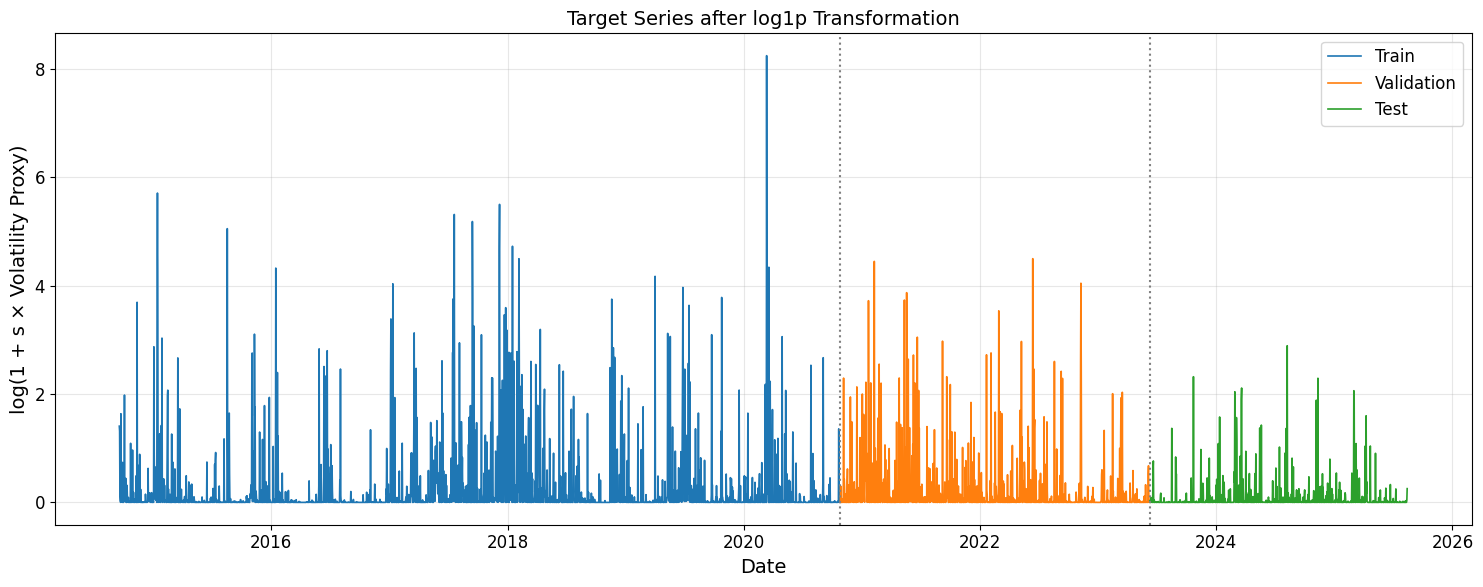

In [78]:
# Plot transformed target series used by the model
def plot_transformed_target_series(y_train: pd.Series, y_val: pd.Series, y_test: pd.Series, transformation_type: str, figsize=(15, 6)):
    """
    Plot the target series after the selected transformation.
    This shows the exact series used as input target by the forecasting models.
    """

    if not isinstance(y_train, pd.Series) or not isinstance(y_val, pd.Series) or not isinstance(y_test, pd.Series):
        raise TypeError("y_train, y_val and y_test must be pandas Series.")

    y_train_plot = y_train.copy()
    y_val_plot = y_val.copy()
    y_test_plot = y_test.copy()

    # Ensure datetime index when possible
    y_train_plot.index = pd.to_datetime(y_train_plot.index)
    y_val_plot.index = pd.to_datetime(y_val_plot.index)
    y_test_plot.index = pd.to_datetime(y_test_plot.index)

    plt.figure(figsize=figsize)

    plt.plot(y_train_plot.index, y_train_plot.values, label="Train", linewidth=1.2)
    plt.plot(y_val_plot.index, y_val_plot.values, label="Validation", linewidth=1.2)
    plt.plot(y_test_plot.index, y_test_plot.values, label="Test", linewidth=1.2)

    # Split lines
    plt.axvline(y_val_plot.index[0], linestyle=":", linewidth=1.5, color="grey")
    plt.axvline(y_test_plot.index[0], linestyle=":", linewidth=1.5, color="grey")

    plt.title(f"Target Series after {transformation_type} Transformation", fontsize=14)
    plt.xlabel("Date", fontsize=14)

    if transformation_type == "original":
        ylabel = "Volatility Proxy"
    elif transformation_type == "log1p":
        ylabel = "log(1 + s × Volatility Proxy)"
    elif transformation_type == "yeo-johnson":
        ylabel = "Yeo-Johnson Transformed Volatility Proxy"
    else:
        ylabel = "Transformed Target"

    plt.ylabel(ylabel, fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_transformed_target_series(y_train=y_train, y_val=y_val, y_test=y_test, transformation_type=transformation_type)

In [80]:
# Summary statistics of transformed target series
summary_transformed_target = pd.DataFrame({"Phase": ["Train", "Validation", "Test"],
                                           "Min": [y_train.min(), y_val.min(), y_test.min()],
                                           "Median": [y_train.median(), y_val.median(), y_test.median()],
                                           "Mean": [y_train.mean(), y_val.mean(), y_test.mean()],
                                           "Std": [y_train.std(ddof=1), y_val.std(ddof=1), y_test.std(ddof=1)],
                                           "Max": [y_train.max(), y_val.max(), y_test.max()]})

display_table(summary_transformed_target, f"Summary statistics - transformed target ({transformation_type}) with factor")


Summary statistics - transformed target (log1p) with factor
╒════╤════════════╤════════╤══════════╤════════╤════════╤════════╕
│    │   Phase    │  Min   │  Median  │  Mean  │  Std   │    Max │
╞════╪════════════╪════════╪══════════╪════════╪════════╪════════╡
│ 0  │   Train    │ 0.0000 │  0.0047  │ 0.2653 │ 0.7072 │ 8.2493 │
├────┼────────────┼────────┼──────────┼────────┼────────┼────────┤
│ 1  │ Validation │ 0.0000 │  0.0086  │ 0.2452 │ 0.6011 │ 4.5006 │
├────┼────────────┼────────┼──────────┼────────┼────────┼────────┤
│ 2  │    Test    │ 0.0000 │  0.0018  │ 0.0995 │ 0.3085 │ 2.8922 │
╘════╧════════════╧════════╧══════════╧════════╧════════╧════════╛
